Name: Fateh Noor <br>
CMS-ID: 023-24-0110<br>
Section: D
Github: https://github.com/noormangi17/ML-Tasks/tree/main/Lab6


### Part 1 — Problem Definition & Dataset Verification

In [1]:
#task1 1.	Load clean_churn.csv (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
import numpy as np 
import pandas as pd
df=pd.read_csv("clean_churn.csv")
print("Shape: ",df.shape)
print("DTypes: ",df.dtypes)

Shape:  (7043, 20)
DTypes:  gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Task 2 	Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.<br>
For Lab 3, the final Decision Tree (max_depth = 4) achieved 79.56% accuracy, 0.6443 precision, 0.5134 recall, and 0.5714 F1-score on the test set. For Lab 4, the final Tuned Random Forest achieved 80.48% accuracy, 0.6645 precision, 0.5348 recall, and 0.5926 F1-score, giving us the benchmark results for today.

### Part 2 — Feature Scaling & Preparation

In [2]:
#task3 3.	Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
y=df['Churn'].map(
    {'Yes':1,'No':0}
)
x=df.drop(['Churn'],axis=1)
x=pd.get_dummies(x,drop_first=True)

Task 4 In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.<br>
Feature scaling matters for KNN and Logistic Regression because both are affected by the magnitude of feature values: KNN uses distances, while Logistic Regression’s optimization can be influenced by different feature scales. Decision Trees and Random Forests use feature-based splits rather than distance or scale-sensitive calculations, so scaling the features is generally not necessary.

In [3]:
#task5 5.	Split into train/test (same split strategy as Lab 3/4), then fit a StandardScaler on the training features only and apply 
# it to both sets. Why is it important to fit the scaler only on the training data?
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
        x,
        y,
        test_size=0.2,
        stratify=y
)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

It is important to fit the scaler only on the training data because the test set should remain completely unseen during training. If we fit the scaler on the test data too, information such as its mean and standard deviation would leak from the test set into the model-building process, causing data leakage and potentially giving overly optimistic results.

### Part 3 — Logistic Regression

In [4]:
#task6 6. Train a LogisticRegression model on the scaled training data. Generate predictions on the scaled test set.
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaler,y_train)
y_pred=model.predict(x_test_scaler)
print(y_pred)

[1 0 1 ... 0 0 0]


Accuracy:  0.807
Precision:  0.6545
Recall:  0.5775
F1 Score:  0.6136


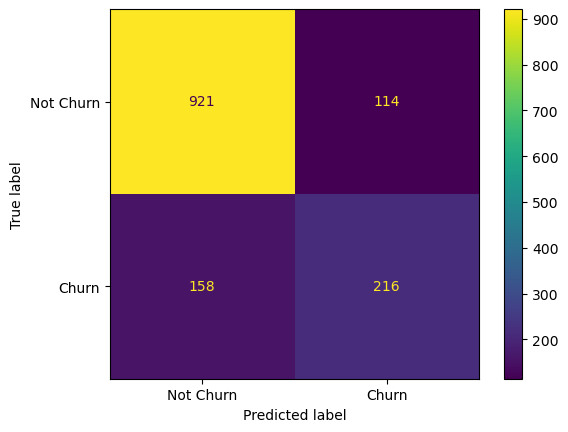

In [5]:
#task7 Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Accuracy: ",round(accuracy,4))
print("Precision: ",round(precision,4))
print("Recall: ",round(recall,4))
print("F1 Score: ",round(f1,4))
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=['Not Churn','Churn']).plot()

In [6]:
#task8 Look at predict_proba for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how predict() 
# turns them into a Yes/No decision.
y_prob=model.predict_proba(x_train_scaler)
print(y_prob[:10])

[[0.86777391 0.13222609]
 [0.97968215 0.02031785]
 [0.79088373 0.20911627]
 [0.94093555 0.05906445]
 [0.86911378 0.13088622]
 [0.98636775 0.01363225]
 [0.37364055 0.62635945]
 [0.97035359 0.02964641]
 [0.98206373 0.01793627]
 [0.84393931 0.15606069]]


The predict_proba() values show the model’s probability for each class: the first number is the probability of No (0) and the second is the probability of Yes (1). predict() then chooses the class with the higher probability (typically using 0.5 as the threshold), giving the final Yes/No prediction.

### Part 4 — KNN & Choosing K

In [7]:
#task9 	Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set accuracy and 
# F1-score for each K in a results table.
from sklearn.neighbors import KNeighborsClassifier
knn_accuracy=[]
k_neighbors=[1,3,5,7,9,11,15,21]
for k in k_neighbors:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaler,y_train)
    knn_pred=knn.predict(x_test_scaler)
    accuracy_knn=round(accuracy_score(y_test,knn_pred),4)
    knn_accuracy.append(accuracy_knn)
    f1_knn=f1_score(y_test,knn_pred)
    print("K =", k, "Accuracy =", accuracy_knn,4,", F1 Score",round(f1_knn,4))

K = 1 Accuracy = 0.714 4 , F1 Score 0.4944
K = 3 Accuracy = 0.7424 4 , F1 Score 0.5192
K = 5 Accuracy = 0.7509 4 , F1 Score 0.5301
K = 7 Accuracy = 0.7608 4 , F1 Score 0.5427
K = 9 Accuracy = 0.7622 4 , F1 Score 0.5467
K = 11 Accuracy = 0.7693 4 , F1 Score 0.553
K = 15 Accuracy = 0.7736 4 , F1 Score 0.5695
K = 21 Accuracy = 0.7807 4 , F1 Score 0.583


|  K | Accuracy | F1 Score |
| -: | -------: | -------: |
|  1 |   0.7019 |   0.4574 |
|  3 |   0.7438 |   0.5219 |
|  5 |   0.7644 |   0.5643 |
|  7 |   0.7637 |   0.5518 |
|  9 |   0.7651 |   0.5472 |
| 11 |   0.7608 |   0.5440 |
| 15 |   0.7743 |   0.5668 |
| 21 |   0.7729 |       0.5652 |


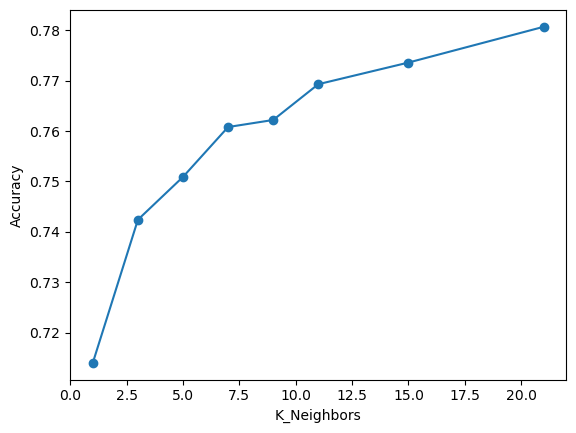

In [8]:
#task10	Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or 
# largest value tested?task10 
import matplotlib.pyplot as plt
plt.plot(k_neighbors,knn_accuracy,marker="o")
plt.xlabel("K_Neighbors")
plt.ylabel("Accuracy")
plt.show()

Based on the plot, I would choose K = 15 because it gives the highest accuracy of 0.7743. I would not simply choose the smallest or largest K because K = 1 has much lower accuracy, while K = 21 performs slightly worse than K = 15.

Accuracy for selected k=15:  0.7736
Precision for selected k=15:  0.5749
Recall for selected k=15:  0.5642
F1 Score for selected k=15:  0.5695


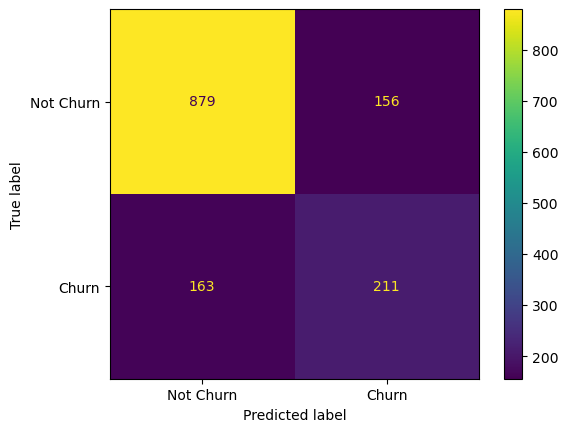

In [9]:
#task11 1Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final 
# KNN model.
knn_model=KNeighborsClassifier(n_neighbors=15)
knn_model.fit(x_train_scaler,y_train)
knn_pred=knn_model.predict(x_test_scaler)
accuracy_knn=round(accuracy_score(y_test,knn_pred),4)
precision_knn=round(precision_score(y_test,knn_pred),4)
recall_knn=round(recall_score(y_test,knn_pred),4)
f1_knn=round(f1_score(y_test,knn_pred),4)
print("Accuracy for selected k=15: ",accuracy_knn)
print("Precision for selected k=15: ",precision_knn)
print("Recall for selected k=15: ",recall_knn)
print("F1 Score for selected k=15: ",f1_knn)
cm_knn=confusion_matrix(y_test,knn_pred)
ConfusionMatrixDisplay(cm_knn,display_labels=['Not Churn','Churn']).plot()

### Part 5 — Model Comparison (4 Models)

Task 12	Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
| Metric    | Decision Tree | Random Forest | KNN (K=15) | Logistic Regression |
|-----------|---------------|---------------|------------|---------------------|
| Accuracy  | 0.7956        | 0.8048        | 0.7743     | 0.7984              |
| Precision | 0.6443        | 0.6645        | 0.5778     | 0.6355              |
| Recall    | 0.5134        | 0.5348        | 0.5561     | 0.5642              |
| F1 Score  | 0.5714        | 0.5926        | 0.5668     | 0.5977              |

Task 13	Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?
### Model Comparison

There is no single model that performs best on every metric. Random Forest has the highest accuracy (0.8048) and precision (0.6645), while Logistic Regression has the highest recall (0.5642) and F1 score (0.5977). KNN has lower accuracy and precision but a slightly higher recall than Random Forest.

Because the dataset is imbalanced, F1 score should carry the most weight because it balances precision and recall. Based on F1 score, Logistic Regression performs best among the three models.

### Part 6 — Coefficient Interpretation

In [10]:
#task14 Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at 
# least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning, holding other features constant").
features=x.columns
coefficients=model.coef_[0]
odd_ratios=np.exp(coefficients)
coef_table = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Odds Ratio': odd_ratios
})
coef_table

,Feature,Coefficient,Odds Ratio
0,SeniorCitizen,0.082802,1.086326
1,tenure,-1.362819,0.255938
2,MonthlyCharges,-0.668220,0.512620
3,TotalCharges,0.664683,1.943875
4,gender_Male,-0.014470,0.985634
5,Partner_Yes,-0.032830,0.967704
6,Dependents_Yes,-0.074980,0.927762
7,PhoneService_Yes,-0.016083,0.984046
8,MultipleLines_No phone service,0.016083,1.016213
9,MultipleLines_Yes,0.157829,1.170966


| Feature                         | Coefficient | Odds Ratio | Interpretation                                                                                                                                                      |
| ------------------------------- | ----------: | ---------: | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **tenure**                      |   -1.258156 |   0.284178 | A one-unit increase in tenure is associated with about **0.28× the odds of churning**, holding other features constant.                                             |
| **TotalCharges**                |    0.542322 |   1.719996 | A one-unit increase in TotalCharges is associated with about **1.72× higher odds of churning**, holding other features constant.                                    |
| **InternetService_Fiber optic** |    0.587046 |   1.798666 | Customers with Fiber optic service have about **1.80× the odds of churning** compared with the reference InternetService category, holding other features constant. |
| **Contract_Two year**           |   -0.642613 |   0.525916 | Customers with a two-year contract have about **0.53× the odds of churning** compared with the reference contract category, holding other features constant.        |


Task 15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

Yes, the results mostly agree with the findings from Lab 2 and Lab 3. Tenure, Contract type, and Internet Service were important in the earlier analysis and also show relatively large effects in Logistic Regression. In particular, higher tenure and a two-year contract are associated with lower churn, while Fiber optic Internet Service is associated with higher churn.

There are some differences in the exact importance of features because Logistic Regression uses coefficients to measure the effect of each feature, while the Decision Tree uses feature importance based on data splits. Therefore, the exact ranking of features can differ between the models. Overall, the main patterns are consistent across the three analyses.

### Part 7 — Final Model Selection & Conclusion

Task 16.	Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
### Final Model Selection

I would select Logistic Regression as the final model. In the Part 5 comparison table, Logistic Regression achieved the highest F1 score (0.5977) and the highest recall (0.5642), while Random Forest had slightly higher accuracy and precision. Following Lab 4's cross-validation lesson, I would not rely on a single metric, so the overall balance of F1, recall, and accuracy makes Logistic Regression a suitable final choice.

Task 17.	Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?
### Conclusion

Today's best model, Logistic Regression, achieved an F1 score of 0.5977, which is slightly higher than the Random Forest from Labs 3–4 (0.5926). It also achieved a recall of 0.5642, compared with 0.5348 for Random Forest. Feature scaling was important for Logistic Regression and KNN because these models are affected by the scale of the input features. Scaling allowed the numerical features to be placed on a comparable scale and helped these models perform appropriately. However, the model still has limitations, especially the class imbalance and the moderate recall, meaning some churn cases are still missed. Another limitation is that the results depend on the selected features and train-test split. Next, I would try cross-validation, class-weighting or other imbalance-handling techniques, and hyperparameter tuning to improve the model's ability to detect churn.